In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the cleaned dataset
df_clean = pd.read_csv("../data/jobstreet_cleaned_final.csv")

In [3]:
# Review the overall size of the cleaned dataset
print("Number of rows:", df_clean.shape[0])
print("Number of columns:", df_clean.shape[1])

Number of rows: 69024
Number of columns: 29


In [4]:
# Convert listingDate into datetime format and count the number of job postings by year
df_clean["listingDate"] = pd.to_datetime(df_clean["listingDate"], errors="coerce")

posting_by_year = df_clean["listingDate"].dt.year.value_counts().sort_index()
posting_by_year

listingDate
2023     1717
2024    57589
2025     9718
Name: count, dtype: int64

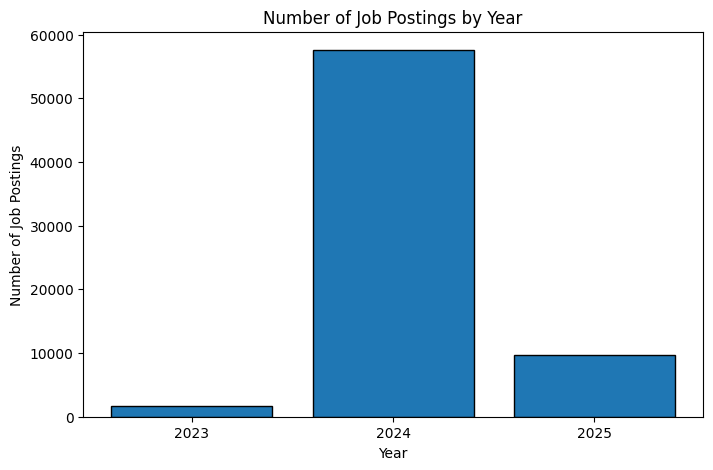

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(posting_by_year.index.astype(str), posting_by_year.values, edgecolor="black")
plt.title("Number of Job Postings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Job Postings")
plt.show()

In [6]:
# Create a function to label each column as original, cleaned, derived, or other
def classify_column(col):
    original_cols = [
        "job_id", "job_title", "company", "descriptions", "location",
        "category", "subcategory", "role", "type", "salary", "listingDate"
    ]
    
    cleaned_cols = [
        "type_clean", "role_clean", "location_clean",
        "salary_clean_text", "state_clean", "descriptions_clean"
    ]
    
    derived_cols = [
        "salary_period", "salary_min", "salary_max", "salary_mid",
        "salary_monthly_est", "salary_has_number", "salary_parse_issue_flag",
        "salary_suspicious_flag", "salary_monthly_final", "salary_usable_flag",
        "description_length", "description_invalid_flag"
    ]
    
    if col in original_cols:
        return "original"
    elif col in cleaned_cols:
        return "cleaned"
    elif col in derived_cols:
        return "derived"
    else:
        return "other"

# Build a summary table that shows column name, data type, and number of missing values
column_summary = pd.DataFrame({
    "columns": df_clean.columns,
    "data_type": df_clean.dtypes.astype(str).values,
    "missing_values": df_clean.isna().sum().values
})

# Add a new column to identify whether each field is original, cleaned, or derived
column_summary["column_type"] = column_summary["columns"].apply(classify_column)

column_summary

,columns,data_type,missing_values,column_type
0,job_id,int64,0,original
1,job_title,str,0,original
2,company,str,0,original
3,descriptions,str,0,original
4,location,str,0,original
5,category,str,0,original
6,subcategory,str,0,original
7,role,str,2252,original
8,type,str,0,original
9,salary,str,37430,original


In [7]:
# Create a summary table of missing values and missing percentages for each column
missing_summary = pd.DataFrame({
    "columns": df_clean.columns,
    "missing_values": df_clean.isna().sum().values,
    "missing_percentage": (df_clean.isna().sum().values / len(df_clean) * 100).round(2)
})

missing_summary = missing_summary.sort_values("missing_percentage", ascending=False)
missing_summary

,columns,missing_values,missing_percentage
23,salary_monthly_final,37556,54.41
19,salary_monthly_est,37520,54.36
18,salary_mid,37520,54.36
16,salary_min,37520,54.36
17,salary_max,37520,54.36
14,salary_clean_text,37430,54.23
15,salary_period,37430,54.23
9,salary,37430,54.23
7,role,2252,3.26
26,descriptions_clean,21,0.03


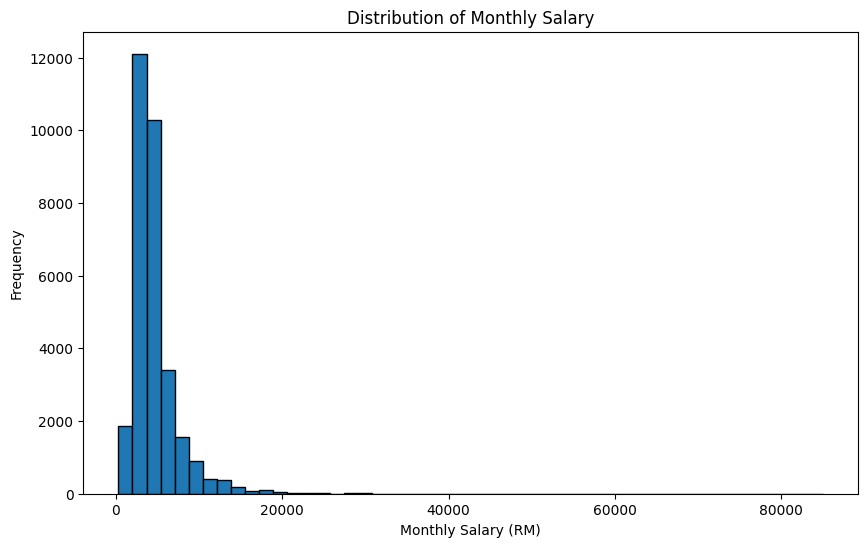

In [8]:
# Plot the distribution of final monthly salary values
plt.figure(figsize=(10, 6))
plt.hist(df_clean["salary_monthly_final"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Monthly Salary")
plt.xlabel("Monthly Salary (RM)")
plt.ylabel("Frequency")
plt.show()

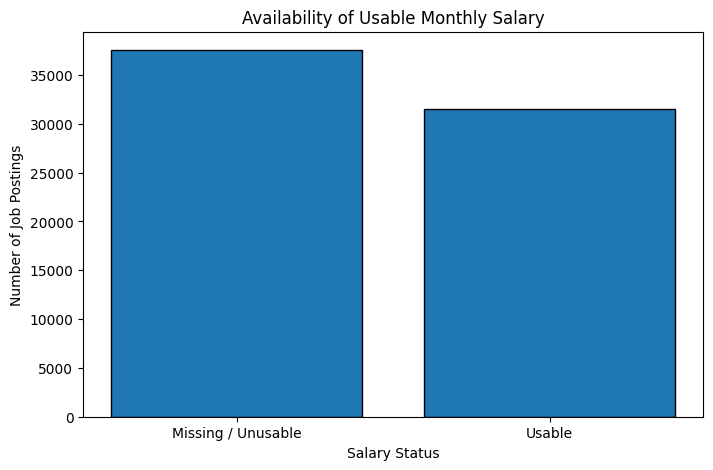

In [9]:
# Count the number of postings with usable and missing or unusable monthly salary values
salary_status = df_clean["salary_usable_flag"].value_counts().sort_index()
salary_status.index = ["Missing / Unusable", "Usable"]

# Create a bar chart to compare salary data availability
plt.figure(figsize=(8, 5))
plt.bar(salary_status.index, salary_status.values, edgecolor="black")
plt.title("Availability of Usable Monthly Salary")
plt.xlabel("Salary Status")
plt.ylabel("Number of Job Postings")
plt.show()

In [10]:
# Count the number of job postings for each state
state_counts = df_clean["state_clean"].value_counts()

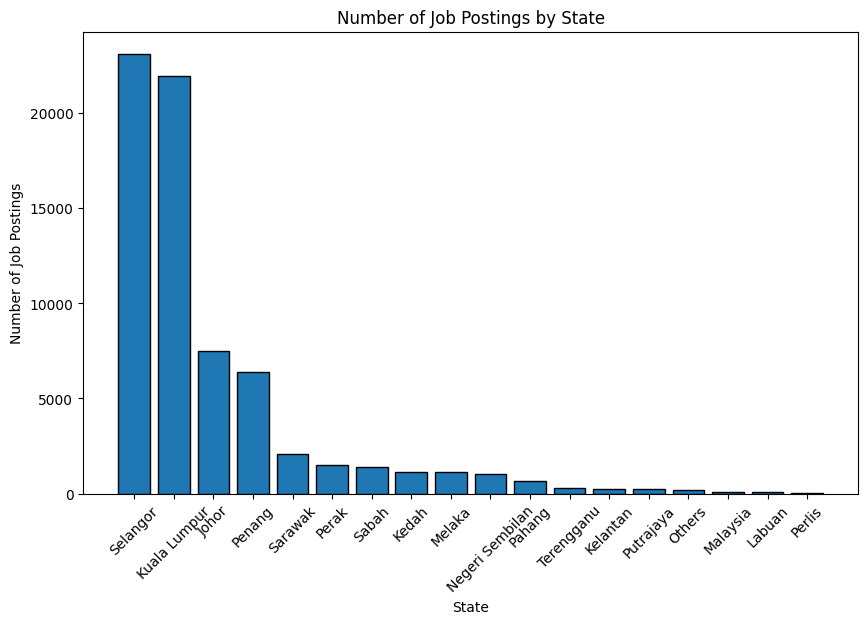

In [11]:
# Create a bar chart to show the distribution of job postings by state
plt.figure(figsize=(10, 6))
plt.bar(state_counts.index, state_counts.values, edgecolor="black")
plt.title("Number of Job Postings by State")
plt.xlabel("State")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.show()

In [12]:
# Count the number of postings in each job category
category_counts = df_clean["category"].value_counts()

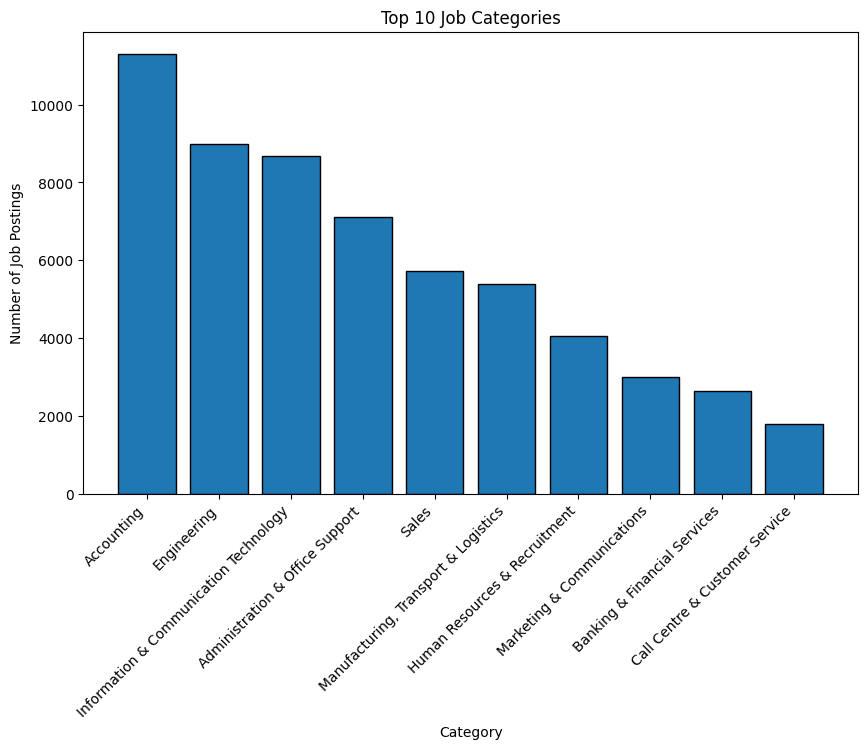

In [13]:
# Select the 10 categories with the highest number of postings
top10_category = df_clean["category"].value_counts().head(10)

# Create a bar chart for the top 10 job categories
plt.figure(figsize=(10, 6))
plt.bar(top10_category.index, top10_category.values, edgecolor="black")
plt.title("Top 10 Job Categories")
plt.xlabel("Category")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.show()

In [14]:
# Count the number of job postings for each cleaned employment type
type_counts = df_clean["type_clean"].value_counts()

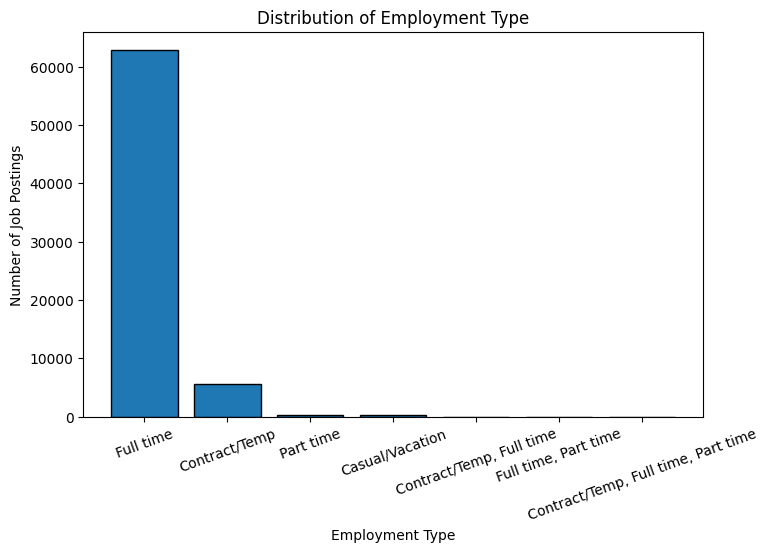

In [15]:
# Create a bar chart to show the distribution of employment type
plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values, edgecolor="black")
plt.title("Distribution of Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=20)
plt.show()

In [16]:
# Calculate the median monthly salary for each job category
salary_by_category = (
    df_clean.groupby("category")["salary_monthly_final"]
    .median()
    .sort_values(ascending=False)
)

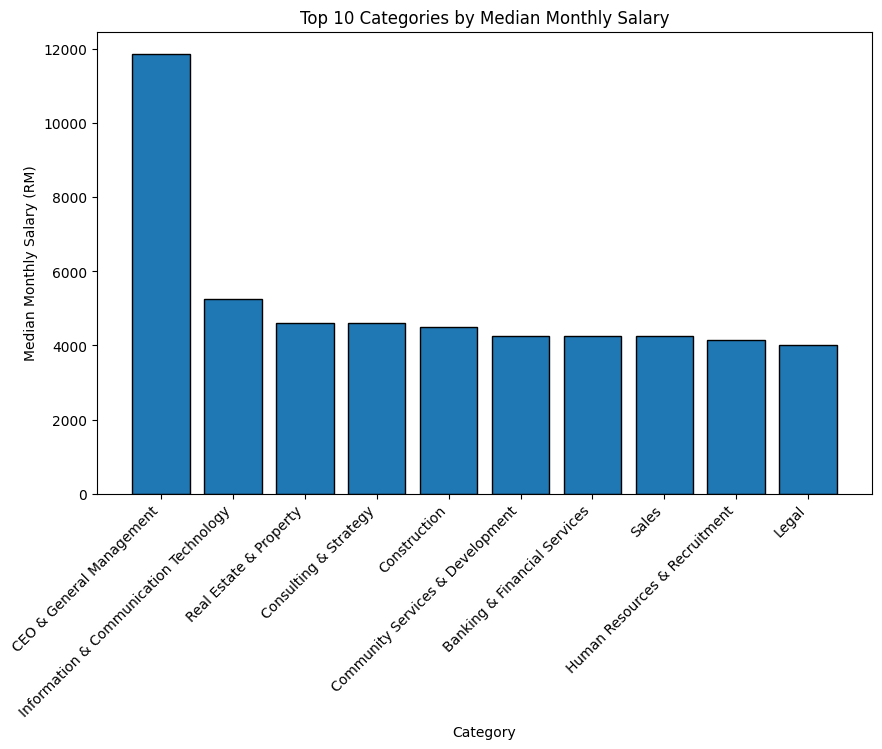

In [17]:
# # Select the top 10 categories with the highest median monthly salary
top10_salary_category = salary_by_category.head(10)

# # Create a bar chart to compare the top 10 categories by median salary
plt.figure(figsize=(10, 6))
plt.bar(top10_salary_category.index, top10_salary_category.values, edgecolor="black")
plt.title("Top 10 Categories by Median Monthly Salary")
plt.xlabel("Category")
plt.ylabel("Median Monthly Salary (RM)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [18]:
# Exclude non specific location groups before comparing salaries across states
salary_by_state_filtered = (
    df_clean.loc[~df_clean["state_clean"].isin(["Malaysia", "Others"])]
    .groupby("state_clean")["salary_monthly_final"]
    .median()
    .sort_values(ascending=False)
)

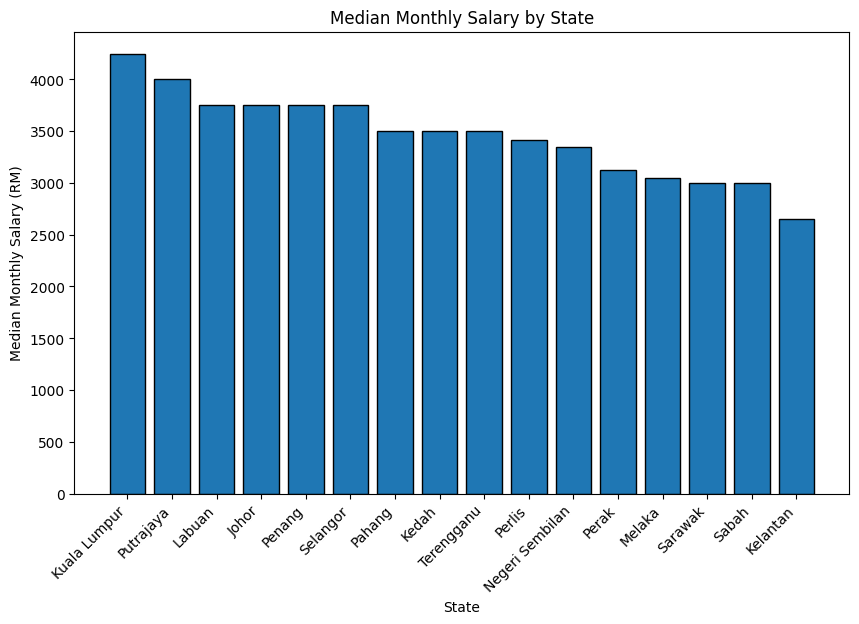

In [19]:
# Create a bar chart to compare median monthly salary by state
plt.figure(figsize=(10, 6))
plt.bar(salary_by_state_filtered.index, salary_by_state_filtered.values, edgecolor="black")
plt.title("Median Monthly Salary by State")
plt.xlabel("State")
plt.ylabel("Median Monthly Salary (RM)")
plt.xticks(rotation=45, ha="right")
plt.show()

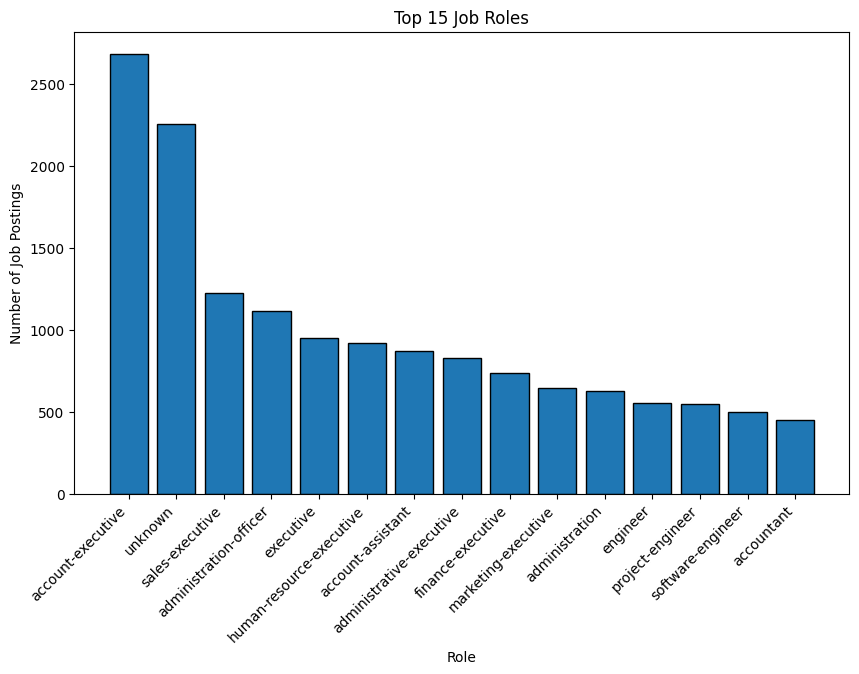

In [20]:
# Count the 15 most frequent cleaned job roles
top15_roles = df_clean["role_clean"].value_counts().head(15)

# Create a bar chart to show the most common job roles
plt.figure(figsize=(10, 6))
plt.bar(top15_roles.index, top15_roles.values, edgecolor="black")
plt.title("Top 15 Job Roles")
plt.xlabel("Role")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.show()

In [21]:
# Keep only records with available salary and a known cleaned role
role_salary_summary = (
    df_clean.loc[
        (df_clean["salary_monthly_final"].notna()) &
        (df_clean["role_clean"] != "unknown")
    ]
    .groupby("role_clean")
    .agg(
        median_salary=("salary_monthly_final", "median"),
        posting_count=("salary_monthly_final", "count")
    )
)

# Keep roles with at least 30 salary records for more reliable comparison
role_salary_summary = role_salary_summary[role_salary_summary["posting_count"] >= 30]
role_salary_summary = role_salary_summary.sort_values("median_salary", ascending=False)

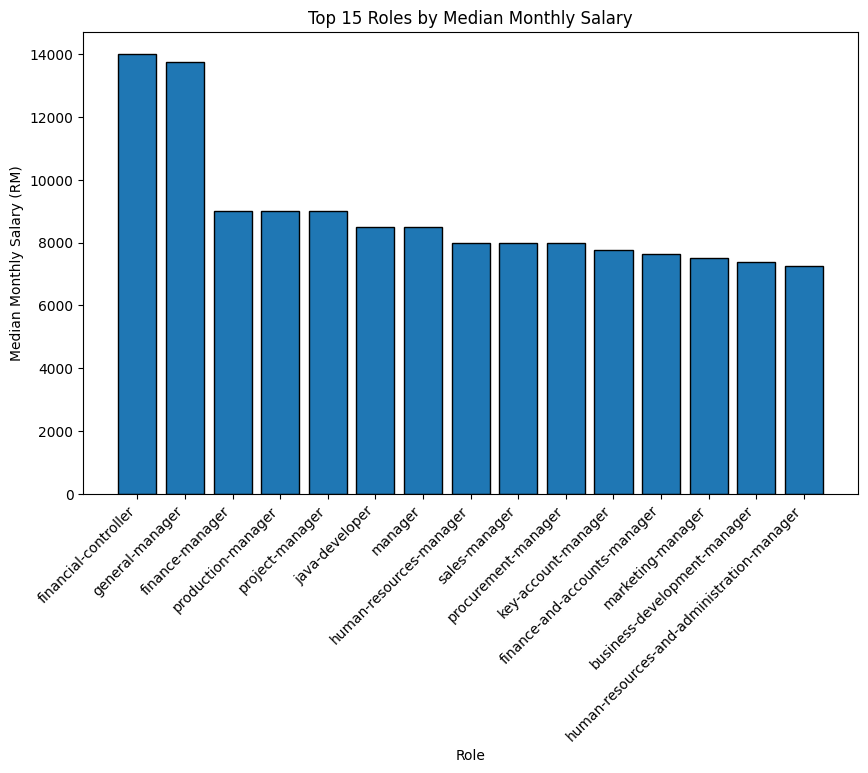

In [22]:
# Select the top 15 highest paying roles
top15_role_salary = role_salary_summary.head(15)

# Create a bar chart for the top 15 roles by median monthly salary
plt.figure(figsize=(10, 6))
plt.bar(top15_role_salary.index, top15_role_salary["median_salary"], edgecolor="black")
plt.title("Top 15 Roles by Median Monthly Salary")
plt.xlabel("Role")
plt.ylabel("Median Monthly Salary (RM)")
plt.xticks(rotation=45, ha="right")
plt.show()

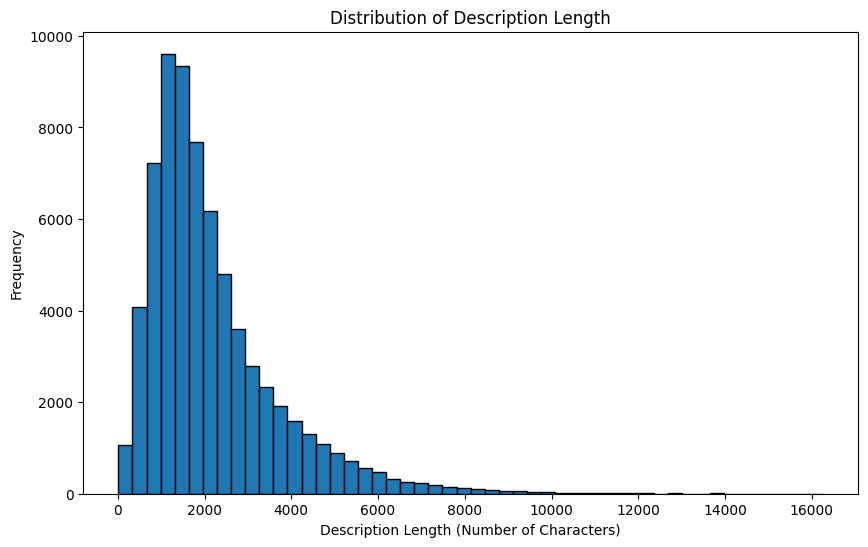

In [23]:
# Plot the distribution of cleaned job description length
plt.figure(figsize=(10, 6))
plt.hist(df_clean["description_length"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Description Length")
plt.xlabel("Description Length (Number of Characters)")
plt.ylabel("Frequency")
plt.show()

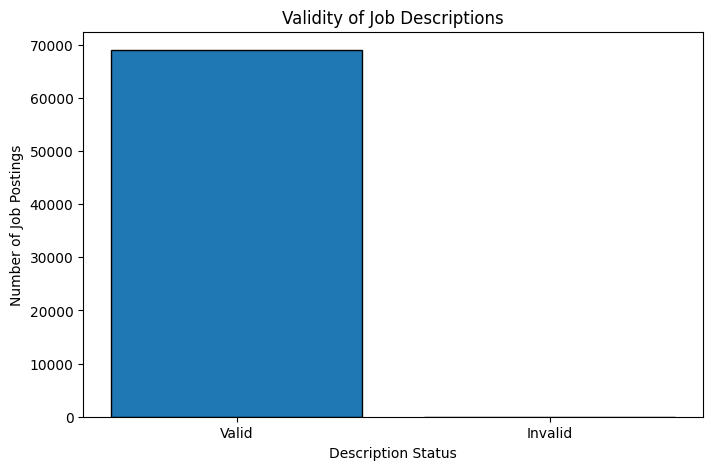

In [24]:
# Count the number of valid and invalid job descriptions
description_status = df_clean["description_invalid_flag"].value_counts().sort_index()
description_status.index = ["Valid", "Invalid"]

# Create a bar chart to show description validity
plt.figure(figsize=(8, 5))
plt.bar(description_status.index, description_status.values, edgecolor="black")
plt.title("Validity of Job Descriptions")
plt.xlabel("Description Status")
plt.ylabel("Number of Job Postings")
plt.show()

In [25]:
# Load the feature-engineered model table produced by 01_features
# It contains only usable-salary rows (RM500-30,000) plus the features engineered from descriptions
import joblib

model_table = pd.read_csv("../data/model_table.csv")
print("Number of rows:", model_table.shape[0])
print("Number of columns:", model_table.shape[1])
print("Total missing values:", int(model_table.isna().sum().sum()))

Number of rows: 31406
Number of columns: 85
Total missing values: 0


In [26]:
# Count how many postings state a required years of experience in the description
exp_status = model_table["has_experience_req"].value_counts().sort_index()
exp_status.index = ["Not stated", "Stated"]
print(exp_status)
print("Percentage stated:", round(exp_status["Stated"] / len(model_table) * 100, 1), "%")

Not stated    15099
Stated        16307
Name: count, dtype: int64
Percentage stated: 51.9 %


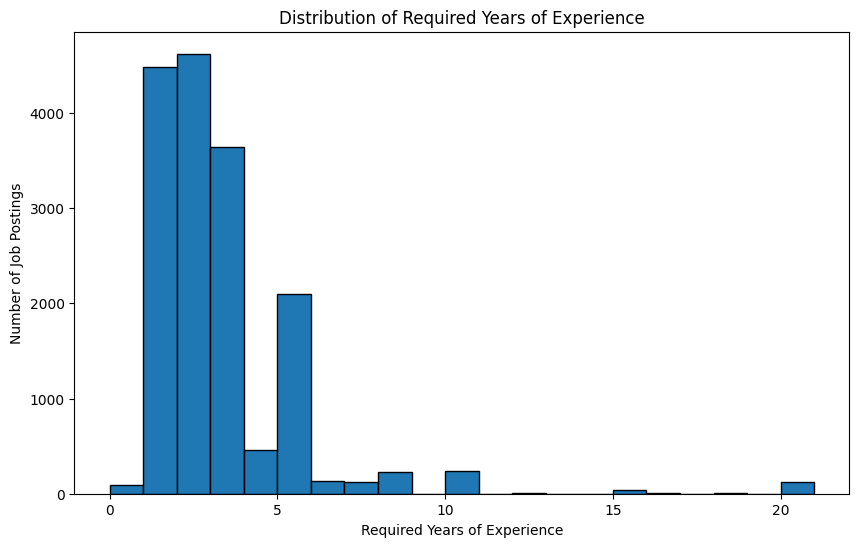

In [27]:
# Plot the distribution of required years of experience (only postings that state it)
stated_years = model_table.loc[model_table["has_experience_req"] == 1, "experience_years"]

plt.figure(figsize=(10, 6))
plt.hist(stated_years, bins=range(0, 22), edgecolor="black")
plt.title("Distribution of Required Years of Experience")
plt.xlabel("Required Years of Experience")
plt.ylabel("Number of Job Postings")
plt.show()

Not stated          9457
SPM / Secondary     2881
Diploma            10434
Bachelor's          8609
Postgraduate          25
Name: count, dtype: int64


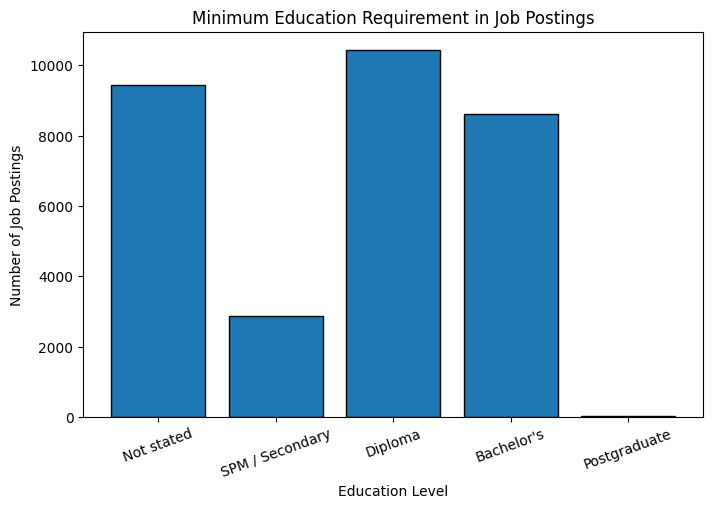

In [28]:
# Count postings at each extracted minimum education requirement level
edu_labels = {0: "Not stated", 1: "SPM / Secondary", 2: "Diploma", 3: "Bachelor's", 4: "Postgraduate"}
edu_counts = model_table["edu_level"].value_counts().sort_index()
edu_counts.index = [edu_labels[level] for level in edu_counts.index]
print(edu_counts)

# Create a bar chart to show the education requirement distribution
plt.figure(figsize=(8, 5))
plt.bar(edu_counts.index, edu_counts.values, edgecolor="black")
plt.title("Minimum Education Requirement in Job Postings")
plt.xlabel("Education Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=20)
plt.show()

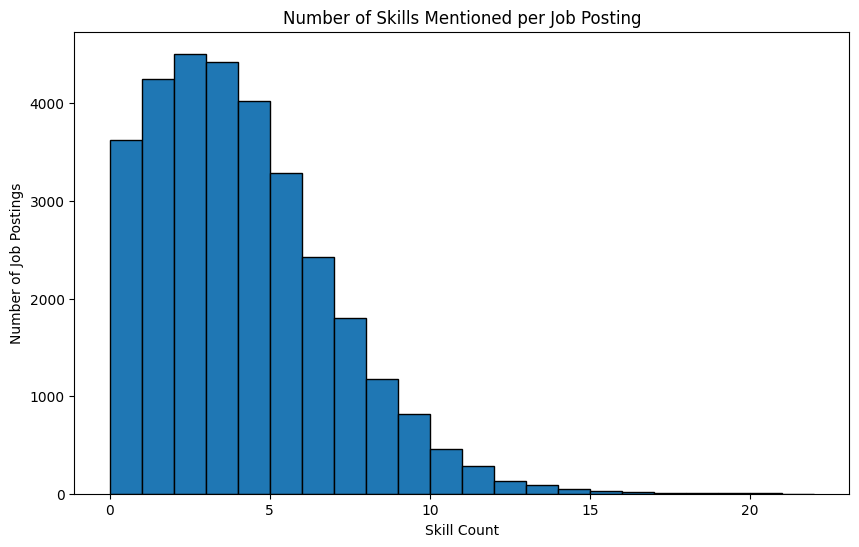

In [29]:
# Plot how many dictionary skills are mentioned per job posting
plt.figure(figsize=(10, 6))
plt.hist(model_table["skill_count"], bins=range(0, int(model_table["skill_count"].max()) + 2), edgecolor="black")
plt.title("Number of Skills Mentioned per Job Posting")
plt.xlabel("Skill Count")
plt.ylabel("Number of Job Postings")
plt.show()

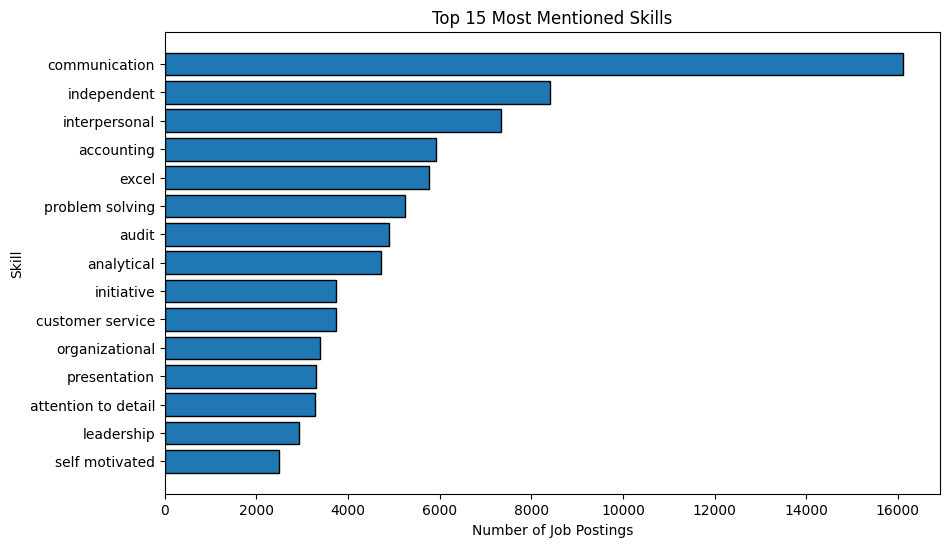

In [30]:
# Load the saved skill list and count the 15 most frequently mentioned skills
skill_lists = joblib.load("../models/skill_lists.joblib")
column_to_skill = {col: skill for skill, col in skill_lists["skill_columns"].items()}

skill_freq = model_table[list(column_to_skill.keys())].sum().sort_values(ascending=False).head(15)
skill_freq.index = [column_to_skill[col] for col in skill_freq.index]

# Create a horizontal bar chart so the skill names stay readable
plt.figure(figsize=(10, 6))
plt.barh(skill_freq.index[::-1], skill_freq.values[::-1], edgecolor="black")
plt.title("Top 15 Most Mentioned Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.show()

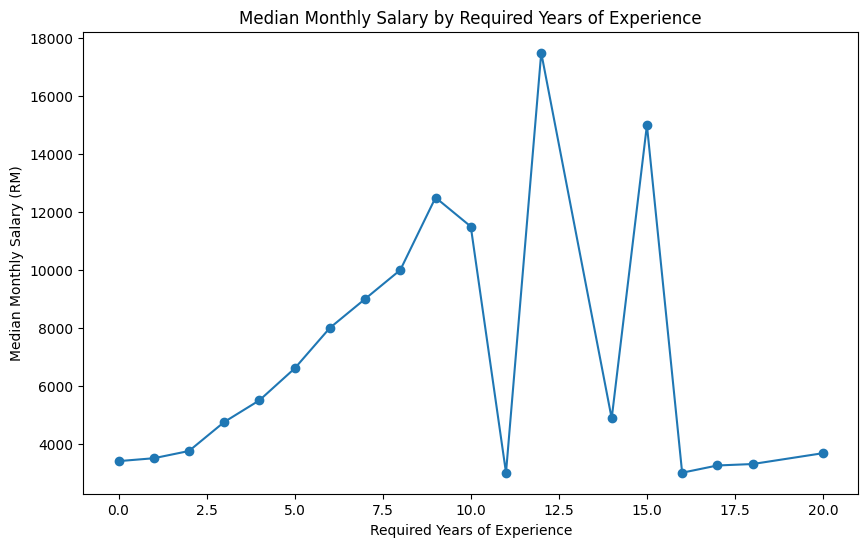

In [31]:
# Compare median salary against required years of experience to confirm the feature carries signal
salary_by_experience = (
    model_table.loc[model_table["has_experience_req"] == 1]
    .groupby("experience_years")["salary_monthly_final"]
    .median()
)

plt.figure(figsize=(10, 6))
plt.plot(salary_by_experience.index, salary_by_experience.values, marker="o")
plt.title("Median Monthly Salary by Required Years of Experience")
plt.xlabel("Required Years of Experience")
plt.ylabel("Median Monthly Salary (RM)")
plt.show()

Not stated         3750.0
SPM / Secondary    3000.0
Diploma            3750.0
Bachelor's         4750.0
Postgraduate       4750.0
Name: salary_monthly_final, dtype: float64


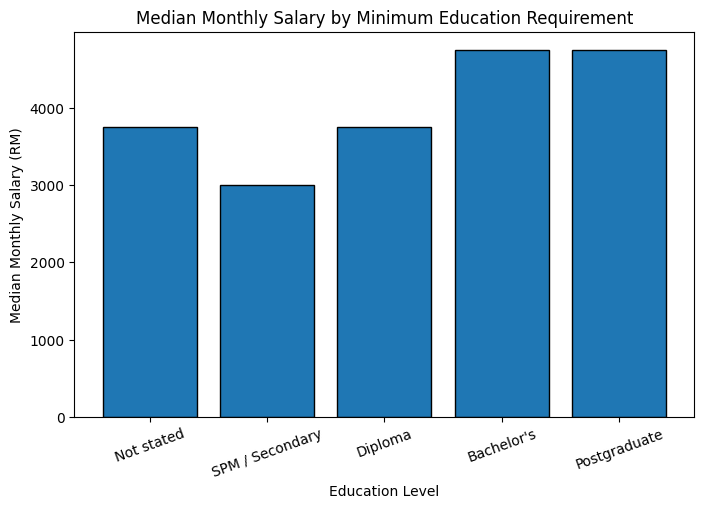

In [32]:
# Compare median salary across education levels
salary_by_edu = model_table.groupby("edu_level")["salary_monthly_final"].median()
salary_by_edu.index = [edu_labels[level] for level in salary_by_edu.index]
print(salary_by_edu)

# Create a bar chart to compare median salary by minimum education requirement
plt.figure(figsize=(8, 5))
plt.bar(salary_by_edu.index, salary_by_edu.values, edgecolor="black")
plt.title("Median Monthly Salary by Minimum Education Requirement")
plt.xlabel("Education Level")
plt.ylabel("Median Monthly Salary (RM)")
plt.xticks(rotation=20)
plt.show()